# 8.1 期货合约基础：升贴水、展期与 Roll Yield

## 为什么期货投资者的实际收益 ≠ 现货价格的上涨幅度？

这是期货市场最重要、也最常被忽视的概念——**展期成本（Roll Cost）**。

### 一个现实例子

2010-2019 年，原油现货价格（WTI）基本在 50-100 美元之间震荡，没有系统性上涨。
但买入石油 ETF（如 USO）的投资者**持续亏损**——原因不是石油跌了，
而是原油期货长期处于 Contango（升水）结构，每月展期都在持续流出收益。

**期货投资的总收益 = 价格收益 + 展期收益（Roll Yield）**

Roll Yield 可以是正的（Backwardation），也可以是持续负的（Contango），
而它对长期持有者的影响，往往比现货价格变动更大！

## 学习目标
- 理解期货合约的标准化要素和交割机制
- 掌握持有成本模型（Cost of Carry）的推导逻辑
- 理解 Contango/Backwardation 的成因
- 量化计算 Roll Yield 对长期持有者的侵蚀


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
print('OK')


OK


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 第一部分：期货定价——为什么期货价格不等于现货？

### 持有成本模型（Cost of Carry）

如果期货价格可以任意偏离公允价值，就会出现无风险套利机会，直到被消除。
所以期货价格必须等于「现货价格 + 持有到到期的成本」：

$$F_{t,T} = S_t \cdot e^{(r + c - y)(T-t)}$$

| 参数 | 含义 | 方向影响 |
|------|------|---------|
| $S_t$ | 当前现货价格 | 基础价格 |
| $r$ | 无风险利率（资金持有成本） | 利率高→期货溢价大 |
| $c$ | 储存成本（如仓储、保险） | 成本高→期货溢价大 |
| $y$ | 便利收益（持有实物的好处） | 便利收益高→期货贴水 |

**Contango（期货升水）**：$F > S$，即 $r + c > y$
- 常见于：石油（储存容易，便利收益低）、黄金（无消费需求）

**Backwardation（期货贴水）**：$F < S$，即 $y > r + c$
- 常见于：农产品丰收季（持有现货的价值高）、季节性紧缺商品


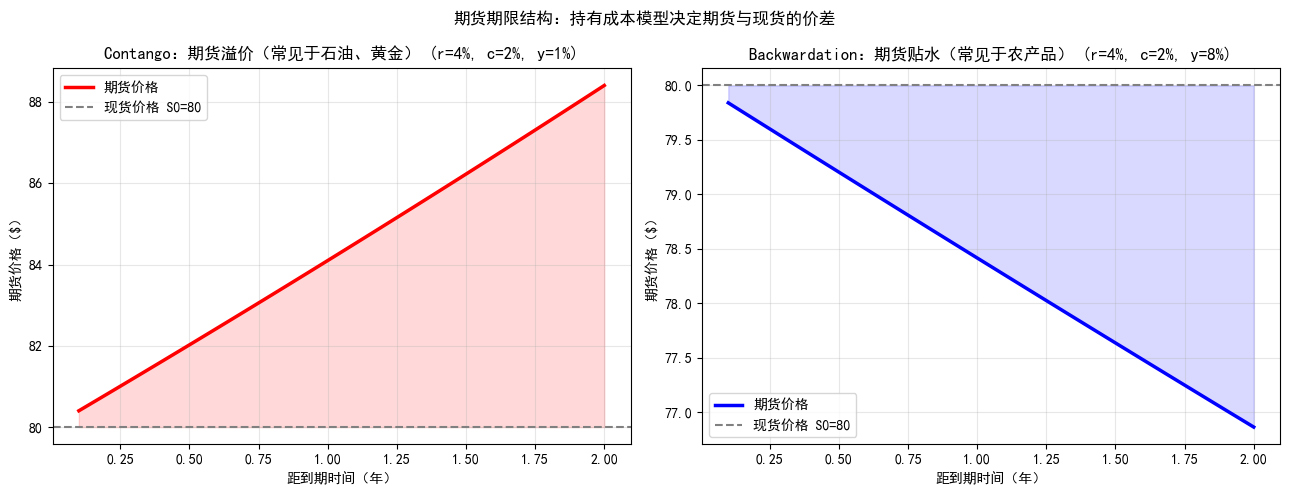

3月后期货: Contango=81.01 (+1.3%)  Backwardation=79.60 (-0.5%)
6月后期货: Contango=82.03 (+2.5%)  Backwardation=79.20 (-1.0%)
12月后期货: Contango=84.10 (+5.1%)  Backwardation=78.42 (-2.0%)


In [4]:
S0 = 80     # 原油现货 $80/桶
r  = 0.04   # 无风险利率 4%
c  = 0.02   # 储存成本 2%（年化）
T_vals = np.linspace(0.1, 2.0, 100)

# Contango: 储存成本 > 便利收益
y_low  = 0.01   # 便利收益低
F_contango = S0 * np.exp((r + c - y_low) * T_vals)

# Backwardation: 便利收益 > 其他成本
y_high = 0.08   # 便利收益高（如季节性紧缺）
F_backwardation = S0 * np.exp((r + c - y_high) * T_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, F, title, color, yval in [
    (axes[0], F_contango, 'Contango：期货溢价（常见于石油、黄金）', 'red', y_low),
    (axes[1], F_backwardation, 'Backwardation：期货贴水（常见于农产品）', 'blue', y_high)]:
    ax.plot(T_vals, F, color=color, lw=2.5, label='期货价格')
    ax.axhline(S0, color='gray', lw=1.5, linestyle='--', label=f'现货价格 S0={S0}')
    ax.fill_between(T_vals, S0, F, alpha=0.15, color=color)
    ax.set_title(f'{title} (r={r:.0%}, c={c:.0%}, y={yval:.0%})')
    ax.set_xlabel('距到期时间（年）'); ax.set_ylabel('期货价格（$）')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('期货期限结构：持有成本模型决定期货与现货的价差', fontsize=12)
plt.tight_layout(); plt.show()

for T in [0.25, 0.5, 1.0]:
    Fc = S0*np.exp((r+c-y_low)*T)
    Fb = S0*np.exp((r+c-y_high)*T)
    print(f'{T*12:.0f}月后期货: Contango={Fc:.2f} (+{(Fc/S0-1):.1%})'
          f'  Backwardation={Fb:.2f} ({(Fb/S0-1):.1%})')


## 第二部分：Roll Yield——展期收益的来源与计算

### 为什么持有期货必须「展期（Roll）」？

期货有到期日，临近交割前持有者必须：
1. **实物交割**（多数投资者不想要几百吨铜）
2. 或**展期**：卖出近月合约，买入远月合约，继续持仓

展期时产生的盈亏：

$$\text{Roll Yield} = \frac{F_{\text{近月}} - F_{\text{远月}}}{F_{\text{近月}}}$$

- **Backwardation**：$F_{\text{近月}} > F_{\text{远月}}$ → Roll Yield > 0（展期每次**赚钱**）
- **Contango**：$F_{\text{近月}} < F_{\text{远月}}$ → Roll Yield < 0（展期每次**亏钱**）

这就是为什么石油 ETF 在原油价格横盘时仍然持续下跌——Contango 的展期成本！


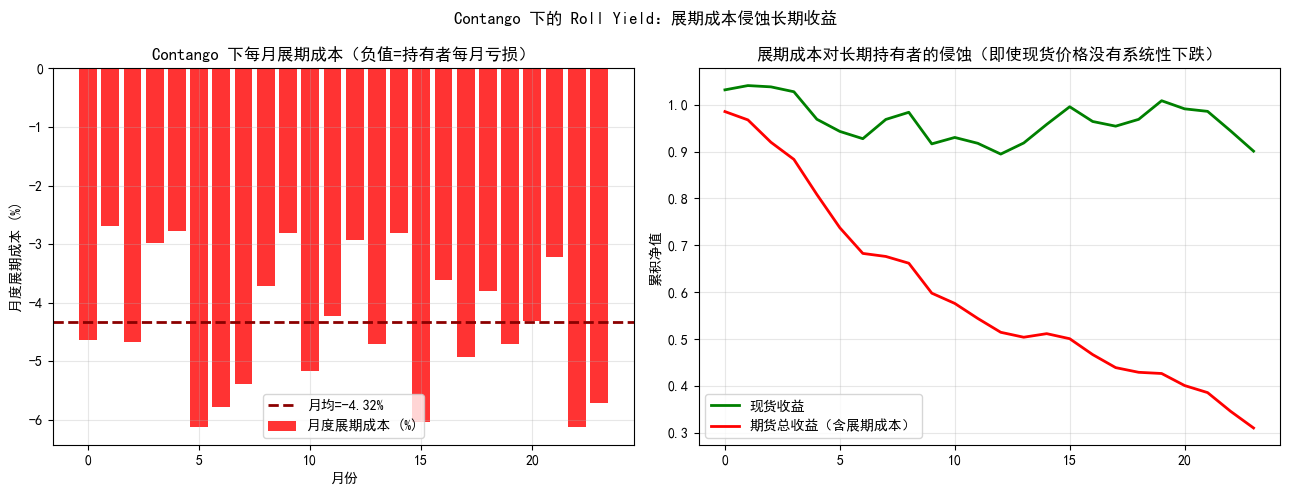

24个月汇总:
  现货累积收益: -9.93%
  期货累积收益: -69.00%
  展期成本吃掉: 59.07%


In [5]:
# 量化 Roll Yield 对长期收益的侵蚀（以原油为例）
np.random.seed(42)
months = 24

near_price = 80 + np.random.normal(0, 3, months)    # 近月价格（随机游走）
# Contango：远月比近月贵 2-5 美元
far_price  = near_price + np.random.uniform(2, 5, months)

roll_yield  = (near_price - far_price) / near_price   # 负数
spot_return = np.random.normal(0.002, 0.04, months)   # 现货月收益

total_futures_return = spot_return + roll_yield        # 期货总收益

cum_spot    = (1 + pd.Series(spot_return)).cumprod()
cum_futures = (1 + pd.Series(total_futures_return)).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(months), roll_yield*100, color=['red' if x<0 else 'green' for x in roll_yield],
            alpha=0.8, label='月度展期成本 (%)')
axes[0].axhline(roll_yield.mean()*100, color='darkred', lw=2, linestyle='--',
                label=f'月均={roll_yield.mean()*100:.2f}%')
axes[0].set_title('Contango 下每月展期成本（负值=持有者每月亏损）')
axes[0].set_xlabel('月份'); axes[0].set_ylabel('月度展期成本 (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(cum_spot, 'green', lw=2, label='现货收益')
axes[1].plot(cum_futures, 'red', lw=2, label='期货总收益（含展期成本）')
axes[1].set_title('展期成本对长期持有者的侵蚀（即使现货价格没有系统性下跌）')
axes[1].set_ylabel('累积净值'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Contango 下的 Roll Yield：展期成本侵蚀长期收益', fontsize=12)
plt.tight_layout(); plt.show()

print(f'24个月汇总:')
print(f'  现货累积收益: {cum_spot.iloc[-1]-1:.2%}')
print(f'  期货累积收益: {cum_futures.iloc[-1]-1:.2%}')
print(f'  展期成本吃掉: {(cum_spot.iloc[-1]-cum_futures.iloc[-1]):.2%}')


## 🎯 练习

1. 查找原油期货（WTI）的历史期限结构数据，计算 2015-2020 年每月的 Roll Yield，哪些时段 Backwardation 最强（Roll Yield 最正）？
2. 对比黄金期货（通常 Contango）和大豆期货（有季节性 Backwardation）的历史 Roll Yield，哪个对长期持有者更友好？
3. 设计一个「Carry 策略」：买入 Roll Yield 最高（最强 Backwardation）的 3 个商品期货品种，做空 Roll Yield 最低（最强 Contango）的 3 个品种，模拟计算年化收益。

---
**下一节** → `02_commodity_momentum.ipynb`